<a href="https://colab.research.google.com/github/andandandand/practical-computer-vision/blob/main/notebooks/Digital_Image_Representation_PIL_NumPy_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial - Digital Image Representation with PIL, NumPy, and PyTorch

#### Author: Antonio Rueda-Toicen

**antonio.rueda.toicen 'at' hpi 'dot' de**


[![Creative Commons License](https://i.creativecommons.org/l/by/4.0/88x31.png)](http://creativecommons.org/licenses/by/4.0/)

This work is licensed under a [Creative Commons Attribution 4.0 International License](http://creativecommons.org/licenses/by/4.0/).

## Three libraries with different purposes

We use:

* PIL (Python Image Library) for storage of images as PNG and JPEG files
* NumPy for image plotting with `matplotlib` and processing of data on the CPU
* PyTorch (aka `torch`) for neural networks and GPU / TPU usage (`CUDA` in NVIDIA GPUs)

All three of these libraries represent images as  "tensors" aka n-dimensional arrays.

## Imports

In [1]:
import torch
import torch.nn as nn
from PIL import Image
import numpy as np
import torchvision.datasets as datasets
import skimage.io as io
import torchvision.transforms.v2 as transforms
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torchvision.models as models
from pathlib import Path
import os

## Shades of gray from the `uint8` type

PIL images use `uint8` by default because:

* 1 byte per pixel component (efficient)
* 256 values (0-255) per channel is enough for human vision
* Industry standard for JPEGs and PNGs
* Maximum compatibility with other software and monitors (256 levels per color channel)

The grid below displays the gray intensity values between 0 and 255 using NumPy and matplotlib.  

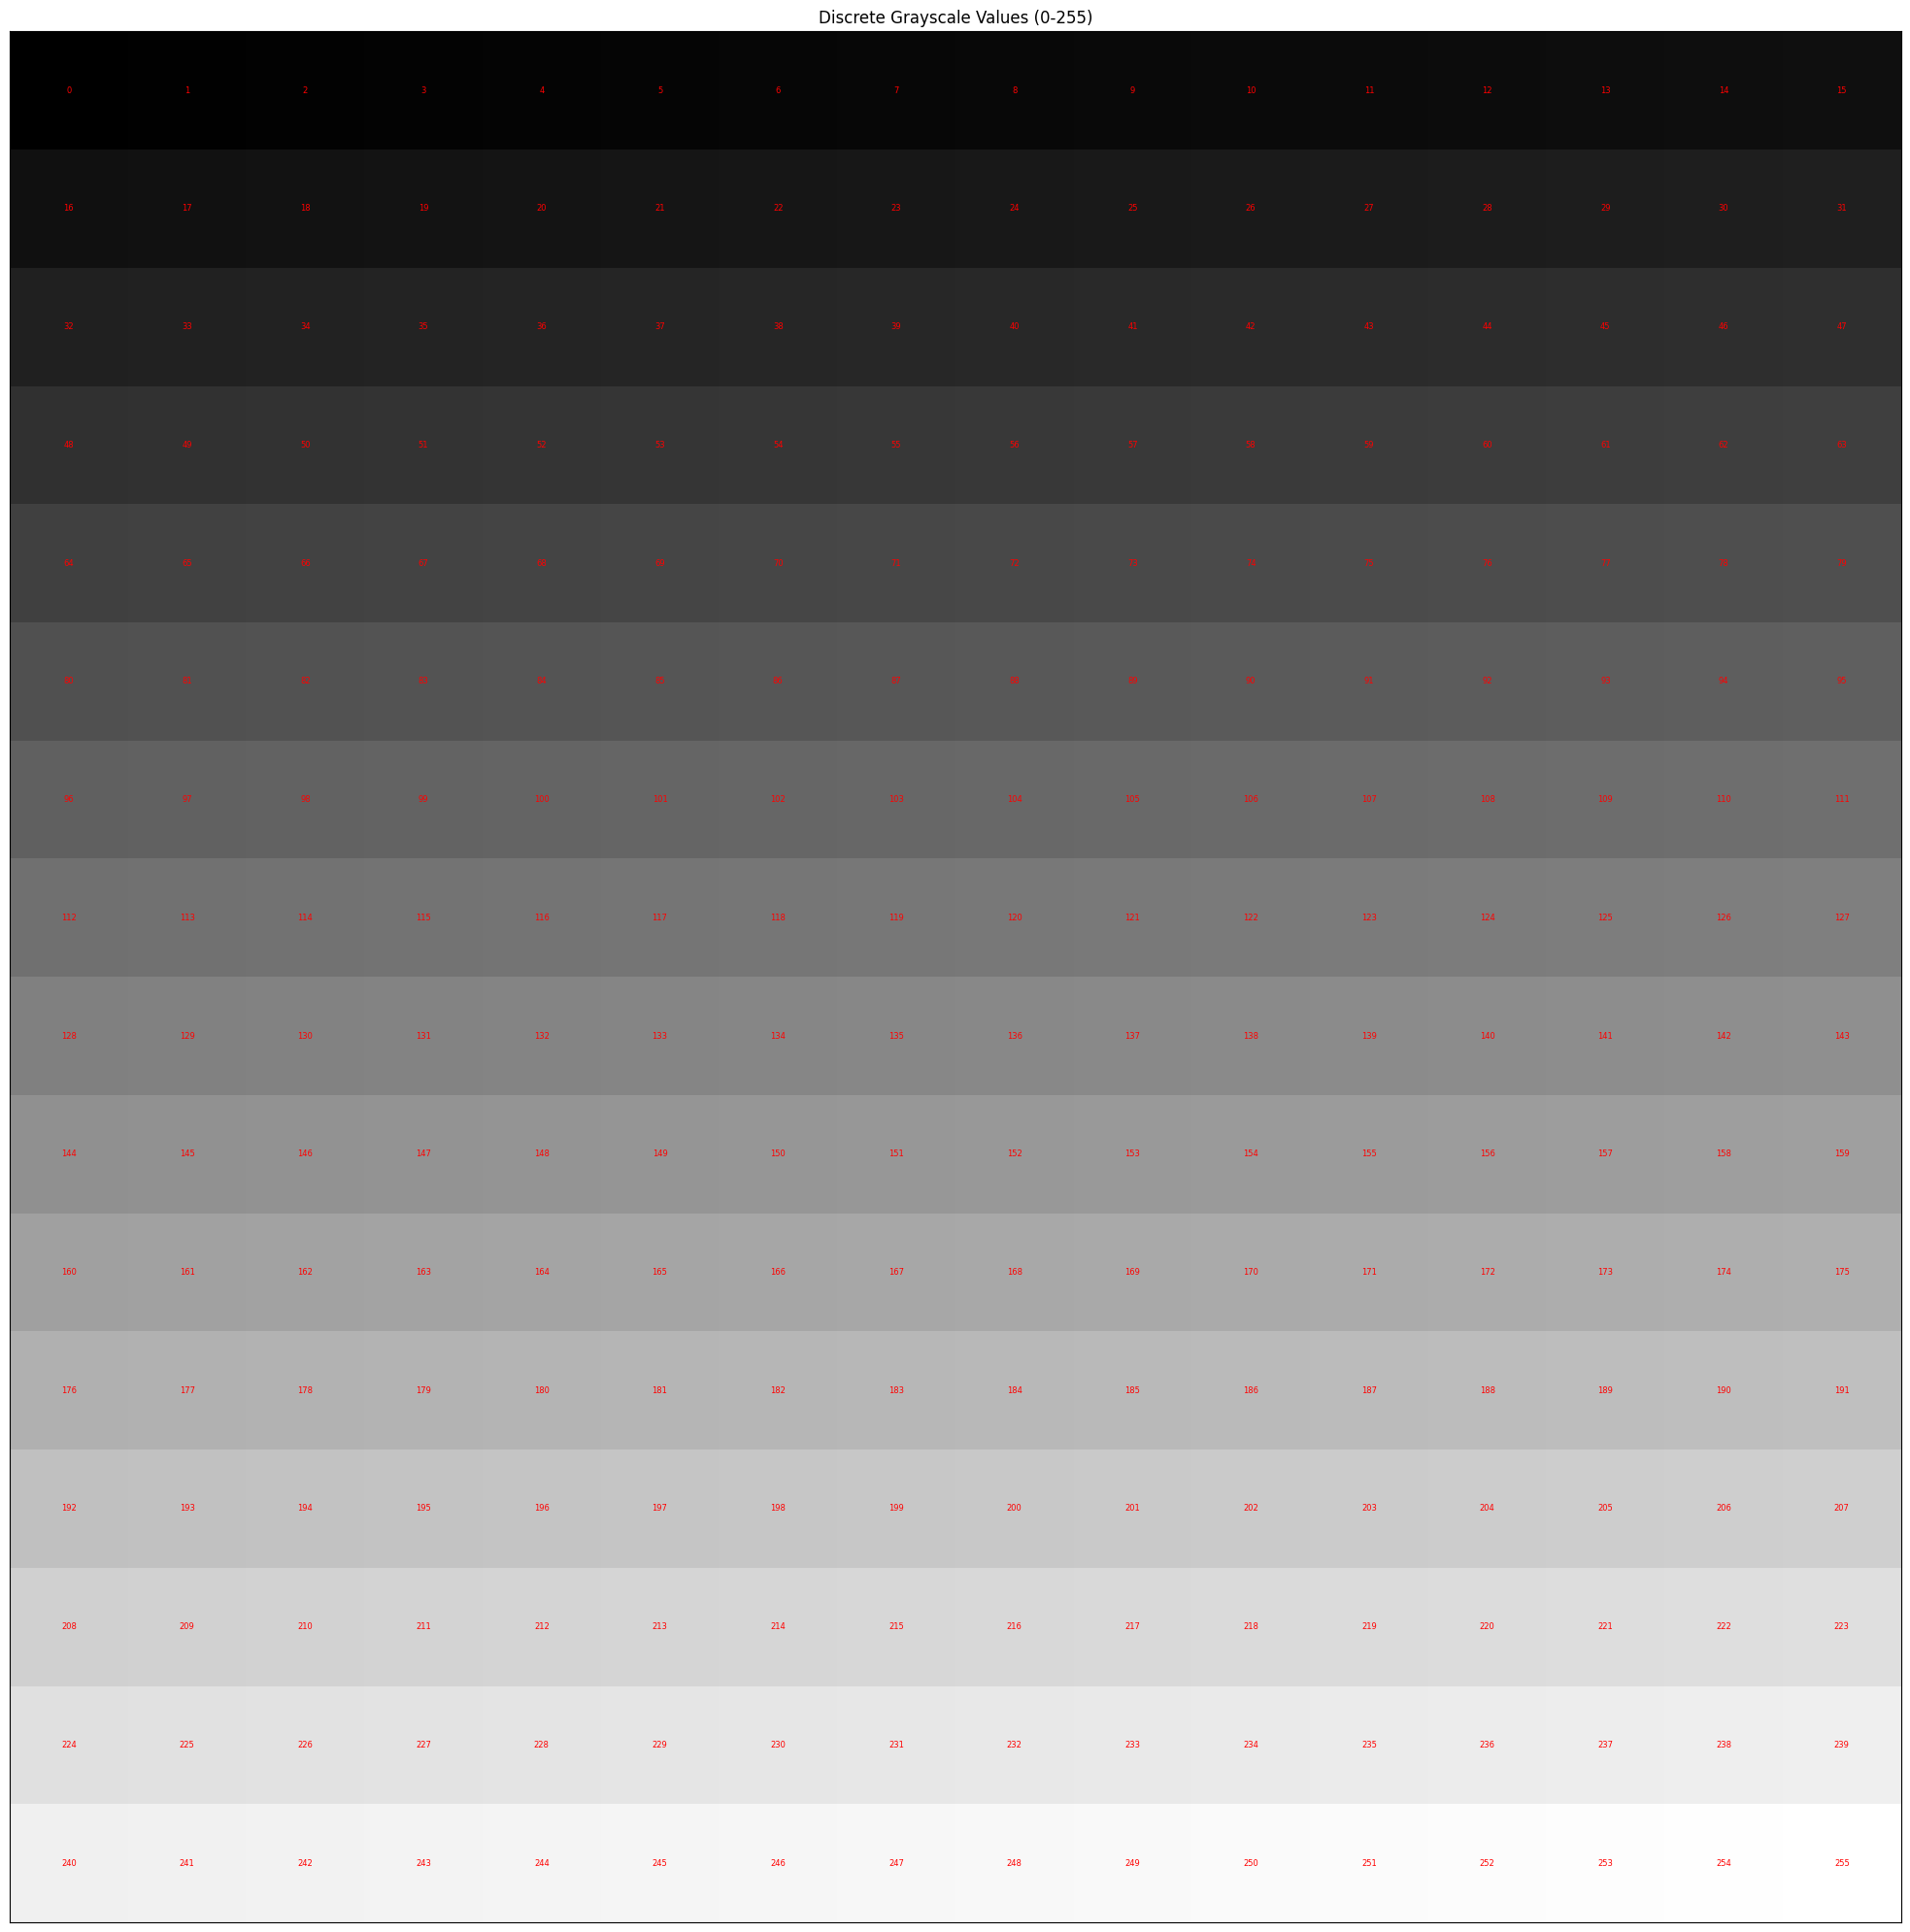

In [2]:
# @title
# Create a figure and axis
fig, ax = plt.subplots(figsize=(20, 20))

# Number of grayscale values (0-255)
num_values = 256

# Calculate the grid dimensions (16x16 grid for 256 values)
grid_size = int(np.sqrt(num_values))
square_size = 1.0

# Initialize the plot with white background
ax.set_xlim(0, grid_size * square_size)
ax.set_ylim(0, grid_size * square_size)
ax.set_aspect('equal')

# Draw each shade of gray as a separate square
for i in range(num_values):
    # Calculate grid position (row, column)
    row = i // grid_size
    col = i % grid_size

    # Calculate position coordinates
    x = col * square_size
    y = (grid_size - 1 - row) * square_size  # Invert y to have 0 at the bottom

    # Calculate gray value (0-1 for matplotlib)
    gray_value = i / 255

    # Create and add the square
    square = Rectangle((x, y), square_size, square_size,
                      facecolor=(gray_value, gray_value, gray_value),
                      edgecolor='none')
    ax.add_patch(square)

    # Add text label (showing value) to every square - all in red
    ax.text(x + square_size/2, y + square_size/2, str(i),
            ha='center', va='center',
            color='red',
            fontsize=6)

# Remove ticks
ax.set_xticks([])
ax.set_yticks([])

# Add title
plt.title('Discrete Grayscale Values (0-255)')


plt.tight_layout()
plt.show()

## Representing colors with RGB in a NumPy n-dimensional array

RGB images are a stack of 3 matrices, each representing an intensity for each color channel. Here we can visualize how they are combined.

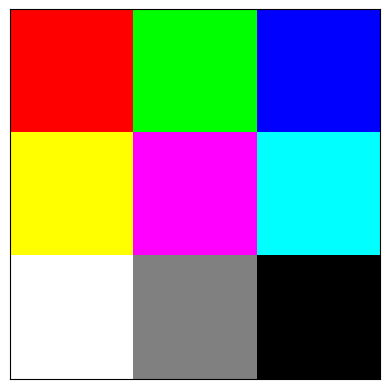

In [3]:
# Create a 3x3 RGB image array
rgb_image = np.array([
   # First row of pixels
   [[255, 0, 0],    # Pure red pixel
    [0, 255, 0],    # Pure green pixel
    [0, 0, 255]],   # Pure blue pixel

   # Second row of pixels
   [[255, 255, 0],  # Yellow pixel (red + green)
    [255, 0, 255],  # Magenta pixel (red + blue)
    [0, 255, 255]], # Cyan pixel (green + blue)

   # Third row of pixels
   [[255, 255, 255],# White pixel (all colors maximum)
    [128, 128, 128],# Gray pixel (all colors at half intensity)
    [0, 0, 0]]      # Black pixel (all colors minimum)
])

plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.imshow(rgb_image);



In [4]:
# We select a row and a column
# Indexing starts at 0, as in standard Python
# We index first with height, then width
pixel = rgb_image[2, 0]

# Will show [255, 255, 255] (white)
# Q: Which index should we use to print magenta’s values?
print(f"RGB values: {pixel}")


RGB values: [255 255 255]


## Image arithmetic and indexing in NumPy

Taken from [source](https://realpython.com/image-processing-with-the-python-pillow-library/).

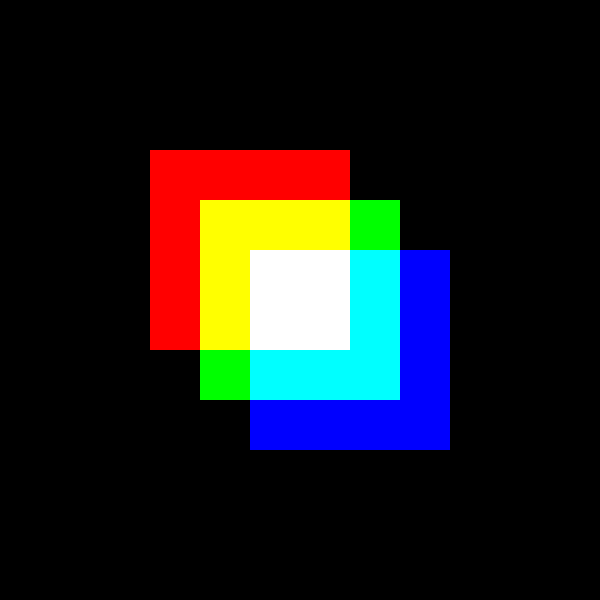

In [5]:
# Create arrays of of zeros
red = np.zeros((600, 600))
green = np.zeros((600, 600))
blue = np.zeros((600, 600))

# Set sections to maximum intensity
red[150:350, 150:350] = 255
green[200:400, 200:400] = 255
blue[250:450, 250:450] = 255

red_img = Image.fromarray(red).convert("L")
green_img = Image.fromarray(green).convert("L")
blue_img = Image.fromarray((blue)).convert("L")

# Merge channels
square_img = Image.merge("RGB", (red_img, green_img, blue_img))
square_img

## The MNIST dataset of grayscale digit images

The [MNIST database](https://en.wikipedia.org/wiki/MNIST_database) is one of the most widely used computer vision datasets. We can download it from `torchvision.datasets` and inspect it through
https://try.fiftyone.ai/datasets/mnist/samples

In [6]:
# Download the MNIST digits from torchvision.datasets
mnist_dataset = datasets.MNIST(
    root="./data",  # Specify the directory to store the dataset
    train=False,    # Download the test set
    download=True,  # Download if not already present
    #transform=transforms.ToImage(),  # Convert PIL images to torch tensors
)

len(mnist_dataset)

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 12.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.72MB/s]


10000

In [7]:
# What we get from the dataset is a list of tuples
# the images come alongside their labels
# Images are already in the PIL image format
mnist_dataset[0]

(<PIL.Image.Image image mode=L size=28x28>, 7)

In [8]:
# PIL images can be saved or read to disk as jpg or png files
mnist_dataset[0][0].save("./mnist_digit.jpg")

In [9]:
# We can check that mnist_digit.jpg has been saved and is
# now a file on our Colab instance
!ls

data  mnist_digit.jpg  sample_data


## Loading JPEG files from disk with PIL

In [10]:
# Now we load the digit from disk
mnist_pil_image = Image.open("./mnist_digit.jpg")
# The digit renders on its true size of 28x28 pixels on Colab
mnist_pil_image

In [11]:
# We have 28 pixels of width, 28 pixels of height
# width is always the first dimension in PIL
width, height = mnist_pil_image.size
width, height

(28, 28)

In [12]:
# Grayscale images have the 'L' mode
mnist_pil_image.mode

'L'

In [13]:
# Convert PIL image to NumPy
mnist_np_array = np.array(mnist_pil_image)
# Check the shape of the array
mnist_np_array.shape

(28, 28)

In [14]:
# We verify that the range of values is between 0 (black) to 255 (white)
mnist_np_array.min(), mnist_np_array.max()

(np.uint8(0), np.uint8(255))

In [15]:
# When they are read, images are uint8
mnist_np_array.dtype

dtype('uint8')

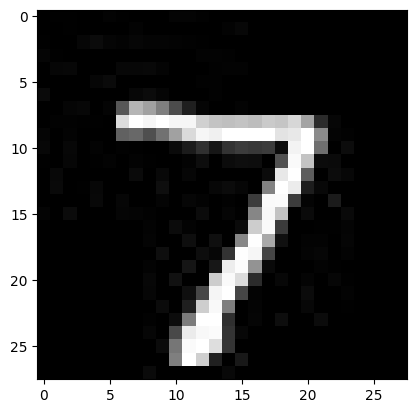

In [16]:
# PIL images are implicitly converted to NumPy and upsampled
# when passed to matplotlib

# Experiment: Verify that the line below produces the same output
# when uncommented
# plt.imshow(mnist_pil_image, cmap="gray");
plt.imshow(mnist_np_array, cmap="gray");


## Negating an image with NumPy

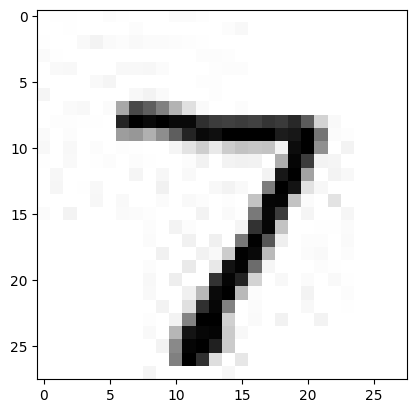

In [17]:
# 255 minus current pixel values with NumPy’s broadcasting
np_array_neg = 255 - mnist_np_array
plt.imshow(np_array_neg, cmap="gray");


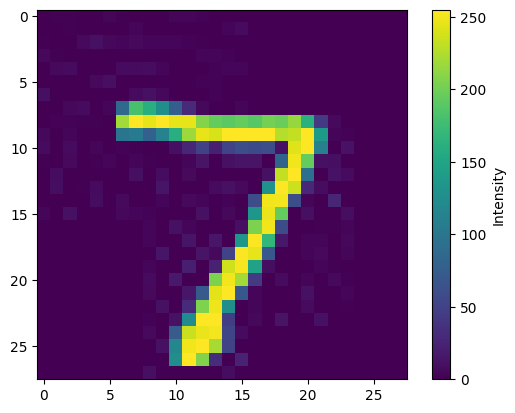

In [18]:
import matplotlib.pyplot as plt

# The default color map (cmap) of matplotlib is 'viridis'
plt.imshow(mnist_pil_image, cmap='viridis')
# We add a colorbar to the plot
plt.colorbar(label='Intensity')
plt.show()

## Intensities for RGB images in NumPy

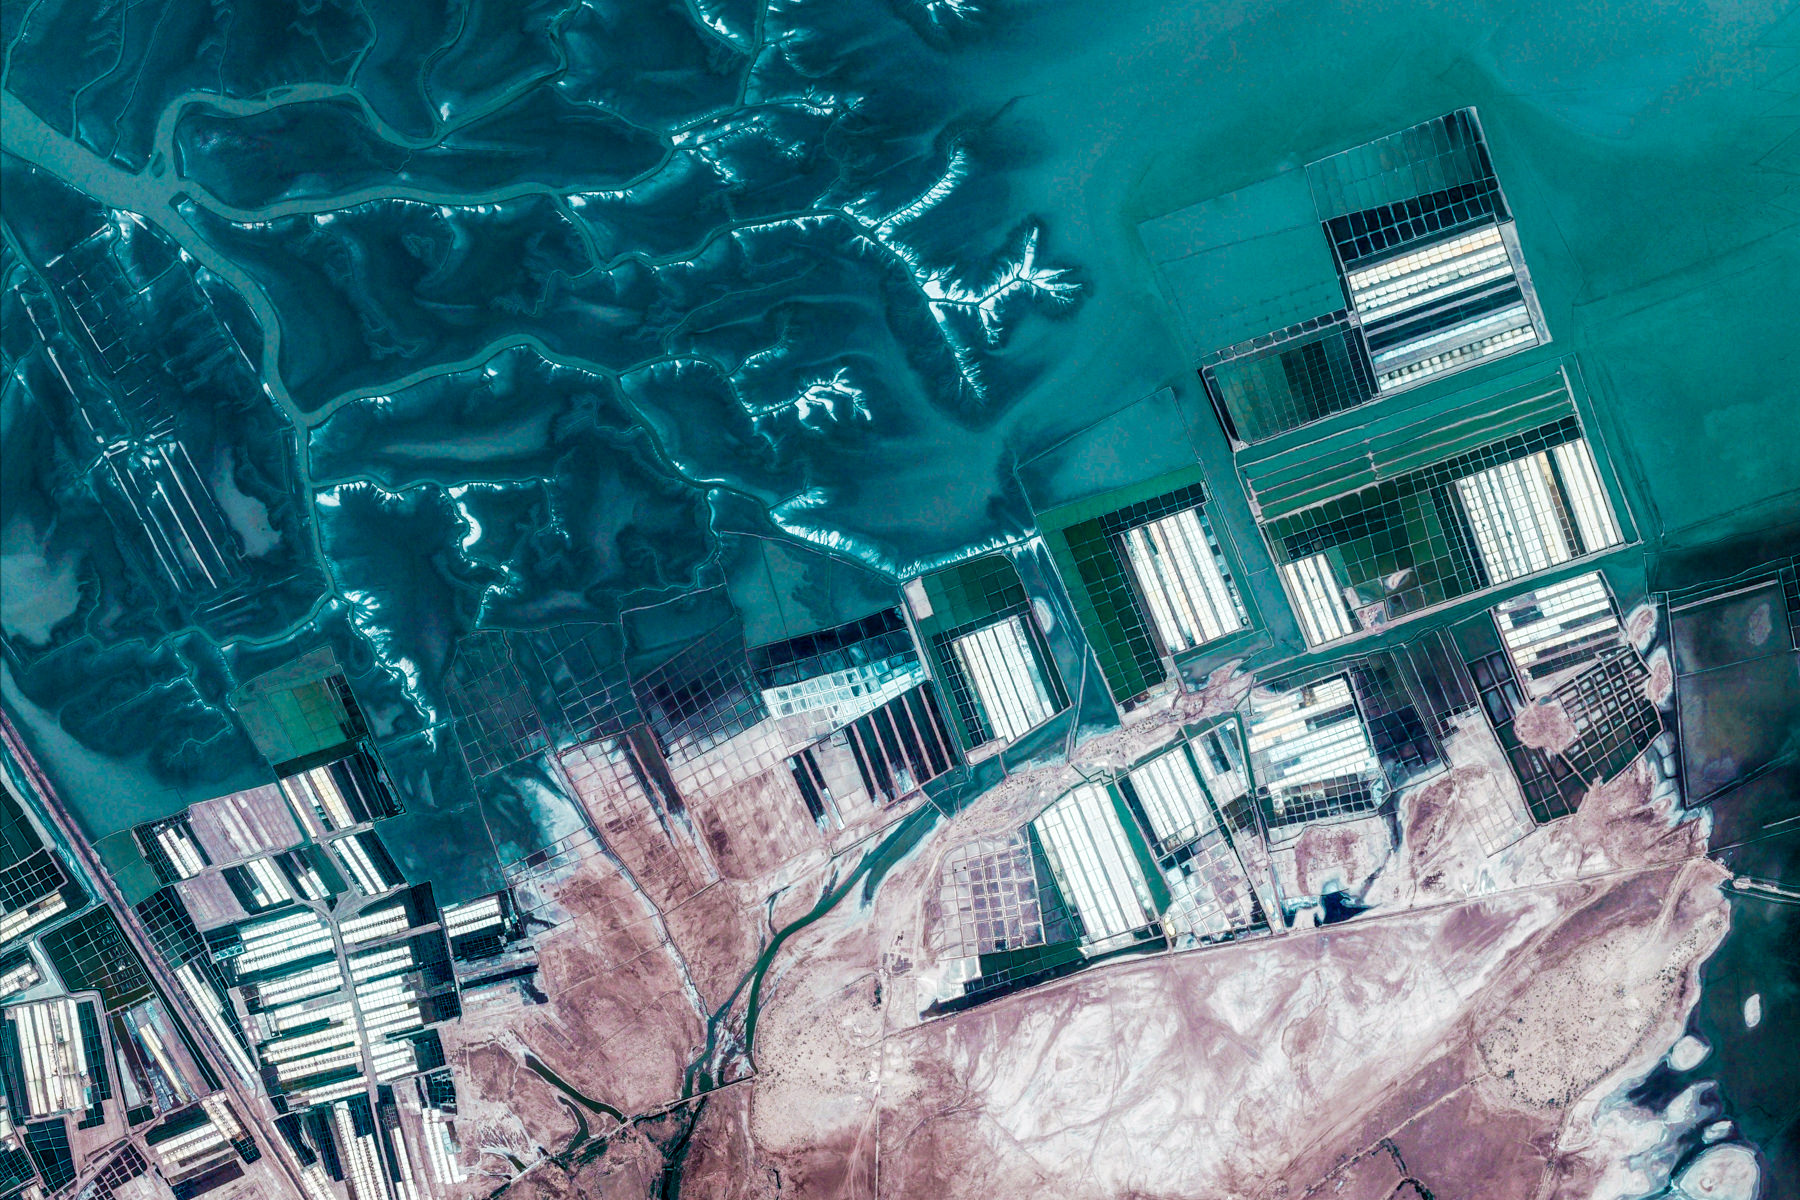

In [19]:
# Images with raw.githubusercontent.com URLs can be imported into Colab with skimage.io.imread(url)
image_url = "https://raw.githubusercontent.com/andandandand/images-for-colab-notebooks/refs/heads/main/gujarat_indien.jpeg"
# The image is loaded as a NumPy array
rgb_np_array = io.imread(image_url)
# We turn the NumPy array into a PIL image
rgb_pil_image = Image.fromarray(rgb_np_array)
rgb_pil_image

In [20]:
# The mode for the color PIL image is RGB
rgb_pil_image.mode

'RGB'

In [21]:
# Images in NumPy are saved as
# Height (H), Width(W), Channels (C)
H, W, C = rgb_np_array.shape
H, W, C

(1200, 1800, 3)

## Plotting individual color channels as intensities

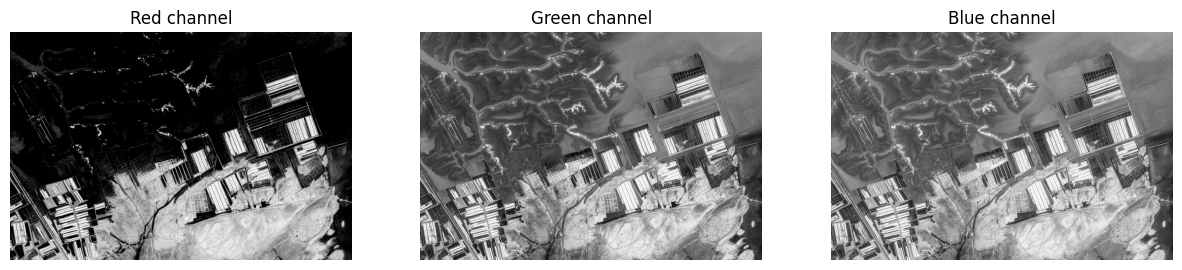

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 15))

# Plot the Red channel
axes[0].imshow(rgb_np_array[:, :, 0], cmap='gray')
axes[0].set_title("Red channel")
axes[0].axis('off')  # Turn off axis ticks and labels

# Plot the Green channel
axes[1].imshow(rgb_np_array[:, :, 1], cmap='gray')
axes[1].set_title("Green channel")
axes[1].axis('off')

# Plot the Blue channel
axes[2].imshow(rgb_np_array[:, :, 2], cmap='gray')
axes[2].set_title("Blue channel")
axes[2].axis('off')

plt.show()

## Adding color to intensity images

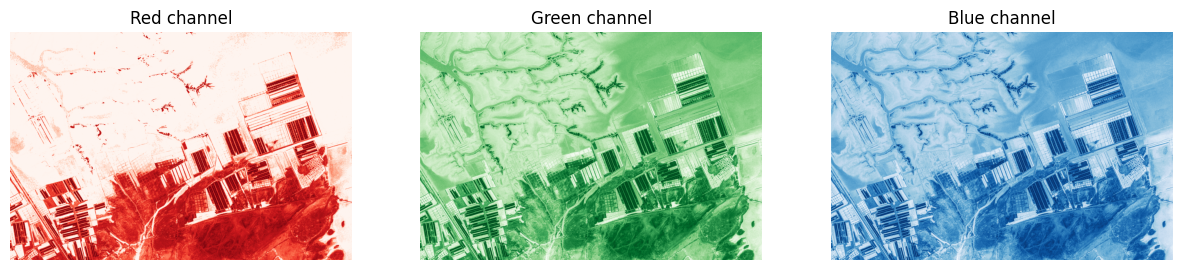

In [23]:
# Create a figure with 3 subplots arranged horizontally
fig, axes = plt.subplots(1, 3, figsize=(15, 15))

# Plot the Red channel
axes[0].imshow(rgb_np_array[:, :, 0], cmap='Reds')
axes[0].set_title("Red channel")
axes[0].axis('off')  # Turn off axis ticks and labels

# Plot the Green channel
axes[1].imshow(rgb_np_array[:, :, 1], cmap='Greens')
axes[1].set_title("Green channel")
axes[1].axis('off')

# Plot the Blue channel
axes[2].imshow(rgb_np_array[:, :, 2], cmap='Blues')
axes[2].set_title("Blue channel")
axes[2].axis('off')

plt.show()

## Intro to `torch` tensors

PyTorch is built for training neural networks. We will use a simple model for digit classification and another pretrained one for the next examples. Don't bother too much about its details now. We delve into the details of these networks in the next sessions.

For now, they are only for us to explore how to work with grayscale and RGB images in `torch`.

In [24]:
# Define a simple MNIST classification model (untrained)
simple_mnist_model = nn.Sequential(
    nn.Flatten(),  # Flatten the 28x28 image into a 784-dimensional vector
    nn.Linear(28 * 28, 128),  # First fully connected layer with 128 units
    nn.ReLU(),  # ReLU activation function
    nn.Linear(128, 10),  # Second fully connected layer with 10 units (for 10 classes)
)

# We won't be training now, so we set the model to evaluation mode.
simple_mnist_model.eval()

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)

In [25]:
# Load a pre-trained ResNet18 model to process color images, we use this model
# just to illustrate the data format needs for neural networks in PyTorch
resnet18 = models.resnet18(weights="IMAGENET1K_V1").eval()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 83.8MB/s]





## Format for the order of color channels in `torch`

To feed tensors to a neural network,
`torch` image tensors should follow the format: `[N, C, H, W]` where:
* `N` = batch size (number of images)
* `C` = channels (e.g., 1 for grayscale, 3 for RGB)
* `H` = height in pixels
* `W` = width in pixels

NumPy arrays follow the `H, W, C` format.

PIL images follow the `W, H` and `mode` format.

It's important to understand that we *can* create tensors that do not follow `[N, C, H, W]` standard, however we cannot feed them to a `torch` neural network (or any other component that is a subclass or `torch.nn.Module`).





## `torch` tensors and `transforms.v2.ToImage()` vs `transforms.ToTensor()`

The `ToImage()` transform reshapes both NumPy arrays and PIL images into the format of `torch` tensors without changing their underlying data type. After applying `ToImage()`, the input becomes a `torch` tensor of type `torch.uint8`.

If the image isn't batched, `ToImage()` will not add a batch dimension.

The batch dimension is important to PyTorch because it needs to know on how many images it is operating when it is feeding data to a neural network.

In [26]:
# ToImage() Converts PIL images with W, H and mode format and NumPy arrays
# with H, W, C format
# to torch tensors with C, H, W format
torch_image_transform = transforms.Compose([transforms.ToImage(),
                                            transforms.ToDtype(torch.float32,
                                                               scale=True)])
rgb_torch_tensor = torch_image_transform(rgb_np_array)
rgb_torch_tensor.shape

torch.Size([3, 1200, 1800])

In [27]:
# Here we get the proper format
mnist_torch_tensor = torch_image_transform(mnist_pil_image)
mnist_torch_tensor.shape

torch.Size([1, 28, 28])

In [28]:
# Q: What happens if we remove transforms.ToDtype(torch.float32, scale=True)?
# Q: What happens if we remove unsqueeze(0)?
# Q: What is the the result of mnist_torch_tensor.unsqueeze(0).shape?
# Q: Why do we grad_fn=<AddmmBackward0> on its output?
simple_mnist_model(mnist_torch_tensor.unsqueeze(0))

tensor([[-0.0985,  0.0183,  0.0315, -0.0279, -0.0931, -0.0375,  0.0471,  0.0070,
          0.0562, -0.0460]], grad_fn=<AddmmBackward0>)

## The rationale for scaling tensors to the 0.0 to 1.0 `float32` range

In [29]:
# Q: Why do we have inf in this tensor?
mnist_tensor_unscaled = transforms.ToImage()(mnist_np_array)
torch.exp(mnist_tensor_unscaled)

tensor([[[1.0000e+00, 2.7183e+00, 2.7183e+00, 1.0000e+00, 1.0000e+00,
          2.0086e+01, 2.7183e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
          5.4598e+01, 5.4598e+01, 7.3891e+00, 1.0000e+00, 1.0000e+00,
          1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
          1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
          1.0000e+00, 1.0000e+00, 1.0000e+00],
         [1.0000e+00, 1.0000e+00, 2.7183e+00, 1.0000e+00, 1.0000e+00,
          1.0000e+00, 1.0000e+00, 2.0086e+01, 1.0000e+00, 1.0000e+00,
          1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 2.0086e+01,
          1.0966e+03, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
          1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
          1.0000e+00, 1.0000e+00, 1.0000e+00],
         [2.7183e+00, 1.0000e+00, 1.0000e+00, 4.0343e+02, 5.9874e+04,
          1.4841e+02, 2.0086e+01, 4.0343e+02, 5.4598e+01, 5.4598e+01,
          2.0086e+01, 7.3891e+00, 2.7183e+00, 1.0000e+00, 1.0000e+

### The deprecated `transforms.ToTensor()` operation

The reshaping performed by `transforms.v2.ToImage()` was previously handled by `transforms.ToTensor()`, but this method has been deprecated because "it did too much" in a single step. In addition to reshaping the tensor to the `C, H, W` format, `transforms.ToTensor()` also divided all values by 255 and converted them to `torch.float32`.

As of March 2025, LLMs like ChatGPT, Gemini, and Claude will still recommend using `transforms.ToTensor()`.

The recommended practice is now to use:

```python
transforms.Compose([transforms.ToImage(), transforms.ToDType(torch.float32, scale=True)])
```

instead of `transforms.ToTensor()`, that will give us a deprecation warning.


In [30]:
# usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.

In [31]:
# Check out the output and the user warning
transforms.ToTensor()(mnist_pil_image)

/usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


tensor([[[0.0000, 0.0039, 0.0039, 0.0000, 0.0000, 0.0118, 0.0039, 0.0000,
          0.0000, 0.0000, 0.0157, 0.0157, 0.0078, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0000, 0.0000, 0.0118,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0118, 0.0275,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0039, 0.0000, 0.0000, 0.0235, 0.0431, 0.0196, 0.0118, 0.0235,
          0.0157, 0.0157, 0.0118, 0.0078, 0.0039, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0196, 0.0039, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0118, 0.0118, 0.0078, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

## Where do `torch` tensors run?

PyTorch is able to run tensors on the GPU or TPU, however by default they are on the CPU. It's important to know that both the `torch` neural network model and the input tensor need to be on the same device.

In [32]:
# We can create torch tensors out of numpy arrays
# keeping their original shape
rgb_torch_tensor = torch.tensor(rgb_np_array)
rgb_torch_tensor.device

device(type='cpu')

In [33]:
# The shape of the torch tensor is the same as the one of the original
# NumPy array, we will need to adjust this before feeding our data to a
# PyTorch neural network
rgb_torch_tensor.shape, rgb_np_array.shape

(torch.Size([1200, 1800, 3]), (1200, 1800, 3))

## The `tensor_name.to(device)` syntax

We use the the `tensor_name.to(device)` syntax to move tensors in and out of the GPU / TPU. To make the GPU or TPU available in Google Colab, go into Runtime -> Change Runtime Type and select your preferred device.


In [34]:
# "cuda" stands for "Compute Unified Device Architecture"
# which is NVIDIA's library for writing GPU code
# it's only available on GPUs or TPUs
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## Creating a FiftyOne dataset

FiftyOne runs on MongoDB and allows us to add a layer of metadata to our image collection. We will use to keep our visualizations and experiments together. This layer of metadata is what we call a fiftyone dataset. The fiftyone app is also a great way to understand our data better.

The only required field for the dataset is a path for each image. We call each added image to the dataset a sample.

We will use `skimage.io` to get images from URLs and `PIL` to save them to local disk as JPEGs.

In [ ]:
!pip install fiftyone==1.4.1 > /dev/null
import fiftyone as fo
fo.__version__

In [ ]:
import os
from pathlib import Path
from PIL import Image
from skimage import io
import numpy as np

# URLs of images to download
urls = ['https://github.com/andandandand/image-dataset-curation/blob/main/images/red_apple_1.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/red_apple_2.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/green_apple_1.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/green_apple_2.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/orange_1.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/orange_2.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/toy_car_1.png?raw=true',
        'https://github.com/andandandand/image-dataset-curation/blob/main/images/toy_car_2.png?raw=true']

# Download and save images
im_arrays = [io.imread(url) for url in urls]
save_path = Path("./apples_oranges_cars")
os.makedirs(save_path, exist_ok=True)
# Convert NumPy arrays in PIL images for storage
pil_images = [Image.fromarray(im_array).convert("RGB") for im_array in im_arrays]

# Save images and track filenames
image_paths = []
for index, imag in enumerate(pil_images):
    filename = f"{Path(urls[index]).stem}.jpg"
    filepath = save_path / filename
    imag.save(filepath)
    image_paths.append(filepath)

print("Images saved to:", os.listdir(save_path))

# Create a FiftyOne dataset from the local images
dataset_name = "apples-oranges-cars"

# Check if the dataset exists
if fo.dataset_exists(dataset_name):
    # Delete existing dataset
    fo.delete_dataset(dataset_name)
    print(f"Existing dataset '{dataset_name}' deleted.")

# Create a new dataset
dataset = fo.Dataset(dataset_name)
print(f"Dataset '{dataset_name}' created.")

# Add image classifications based on filename
for image_path in image_paths:
    # Create a sample with the filepath
    sample = fo.Sample(filepath=str(image_path))

    # Extract a simple label from the filename
    filename = os.path.basename(image_path)
    if "apple" in filename:
        label = "apple"
        if "red" in filename:
            label = "red_apple"
        elif "green" in filename:
            label = "green_apple"
    elif "orange" in filename:
        label = "orange"
    elif "car" in filename:
        label = "toy_car"
    else:
        label = "unknown"

    # Add the classification
    sample["classification"] = fo.Classification(label=label)

    # Add the sample to the dataset
    dataset.add_sample(sample)

# Persist the dataset
dataset.persistent = True
print(f"Dataset info: {dataset}")

# Verify dataset samples and paths
print(f"Number of samples: {len(dataset)}")
print("Sample filepaths:")
for sample in dataset.take(3):
    print(f"  - {sample.filepath} (Label: {sample.classification.label})")

# Launch the FiftyOne App to view the dataset
session = fo.launch_app(dataset, auto=False)

In [ ]:
# Copy and paste the address into your browser window
session.url

## References

* [Image Processing With the Python Pillow Library](https://realpython.com/image-processing-with-the-python-pillow-library/)

* [Transforming and Augmenting Images](https://pytorch.org/vision/main/transforms.html)